In [ ]:
"""
Customer Churn Prediction with KNN
Author: [Markus von Aschoff]
Description: Predict whether a customer will churn using KNN
"""


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report)
import os

CSV_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

def generate_synthetic_telco(n=7043, seed=42):
    """Synthetic Telco-Churn dataset that mirrors the real Kaggle schema."""
    rng = np.random.default_rng(seed)

    gender          = rng.choice(['Male', 'Female'], n)
    senior_citizen  = rng.choice([0, 1], n, p=[0.84, 0.16])
    partner         = rng.choice(['Yes', 'No'], n, p=[0.48, 0.52])
    dependents      = rng.choice(['Yes', 'No'], n, p=[0.30, 0.70])
    tenure          = rng.integers(0, 73, n)
    phone_service   = rng.choice(['Yes', 'No'], n, p=[0.90, 0.10])
    multiple_lines  = np.where(phone_service == 'No', 'No phone service',
                               rng.choice(['Yes', 'No'], n))
    internet_service = rng.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.34, 0.44, 0.22])

    def inet_opt(yes_p=0.43):
        return np.where(internet_service == 'No', 'No internet service',
                        rng.choice(['Yes', 'No'], n, p=[yes_p, 1 - yes_p]))

    contract        = rng.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.21, 0.24])
    paperless       = rng.choice(['Yes', 'No'], n, p=[0.59, 0.41])
    payment_method  = rng.choice(
        ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
        n, p=[0.34, 0.23, 0.22, 0.21])
    monthly_charges = rng.uniform(18.25, 118.75, n).round(2)
    total_charges   = np.where(tenure == 0, np.nan,
                               (tenure * monthly_charges * rng.uniform(0.95, 1.05, n)).round(2))

    churn_logit = (-1.5
        + 0.03 * (monthly_charges - 65)
        - 0.04 * tenure
        + 1.2  * (contract == 'Month-to-month').astype(float)
        - 0.8  * (contract == 'Two year').astype(float)
        + 0.6  * (internet_service == 'Fiber optic').astype(float)
        + 0.4  * (payment_method == 'Electronic check').astype(float))
    churn = np.where(rng.random(n) < 1 / (1 + np.exp(-churn_logit)), 'Yes', 'No')

    return pd.DataFrame({
        'customerID': [f"CUST-{i:05d}" for i in range(n)],
        'gender': gender, 'SeniorCitizen': senior_citizen,
        'Partner': partner, 'Dependents': dependents, 'tenure': tenure,
        'PhoneService': phone_service, 'MultipleLines': multiple_lines,
        'InternetService': internet_service,
        'OnlineSecurity': inet_opt(0.29), 'OnlineBackup': inet_opt(0.34),
        'DeviceProtection': inet_opt(0.34), 'TechSupport': inet_opt(0.29),
        'StreamingTV': inet_opt(0.44), 'StreamingMovies': inet_opt(0.44),
        'Contract': contract, 'PaperlessBilling': paperless,
        'PaymentMethod': payment_method,
        'MonthlyCharges': monthly_charges, 'TotalCharges': total_charges,
        'Churn': churn,
    })

if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH)
    print(f"Loaded real Telco dataset from '{CSV_PATH}'")
else:
    print("CSV not found — generating synthetic Telco dataset (same schema).")
    df_raw = generate_synthetic_telco()

print(f"\nShape: {df_raw.shape}")
df_raw.head()

Loaded real Telco dataset from 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dtypes:")
print(df_raw.dtypes)
print("\nTarget distribution:")
print(df_raw['Churn'].value_counts())
churn_rate = (df_raw['Churn'] == 'Yes').mean()
print(f"\nOverall churn rate: {churn_rate*100:.1f}%")

Dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.5%


### Step 2: Data Preprocessing

In [7]:
df = df_raw.copy()

# Drop customer ID — not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# TotalCharges: coerce to numeric (real dataset stores blanks as ' ')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Report missing values
missing = df.isnull().sum()
print("Missing values before imputation:")
print(missing[missing > 0] if missing.sum() > 0 else "  None")

Missing values before imputation:
TotalCharges    11
dtype: int64


In [8]:
# TotalCharges NaN only for tenure=0 customers → impute with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.dropna().reset_index(drop=True)
print(f"Missing values after imputation: {df.isnull().sum().sum()}")

# Encode target: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Encode gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# One-hot encode remaining categorical columns
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert bool dummies to int for sklearn
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Shape after encoding: {df.shape}")
print(f"\nFeature columns ({df.shape[1]-1} total):")
print([c for c in df.columns if c != 'Churn'])

Missing values after imputation: 0
Shape after encoding: (7043, 31)

Feature columns (30 total):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [9]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Churn (1): {y.sum()}  |  No Churn (0): {(y == 0).sum()}")

Features: 30  |  Samples: 7043
Churn (1): 1869  |  No Churn (0): 5174


### Step 3: Split the Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples  (churn rate: {y_train.mean()*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples  (churn rate: {y_test.mean()*100:.1f}%)")

Training set: 5634 samples  (churn rate: 26.5%)
Test set:     1409 samples  (churn rate: 26.5%)


### Step 4: Train a KNN Model

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN trained successfully!")

y_train_pred = knn.predict(X_train)
y_test_pred  = knn.predict(X_test)
print(f"Predictions generated for {len(y_test_pred)} test samples.")

KNN trained successfully!
Predictions generated for 1409 test samples.


### Step 5: Make Predictions and Evaluate

In [12]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec  = recall_score(y_test, y_test_pred)
test_conf = confusion_matrix(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test Accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nTest Precision:    {test_prec:.4f}")
print(f"Test Recall:       {test_rec:.4f}")

Training Accuracy: 0.8278 (82.78%)
Test Accuracy:     0.7658 (76.58%)

Test Precision:    0.5791
Test Recall:       0.4305


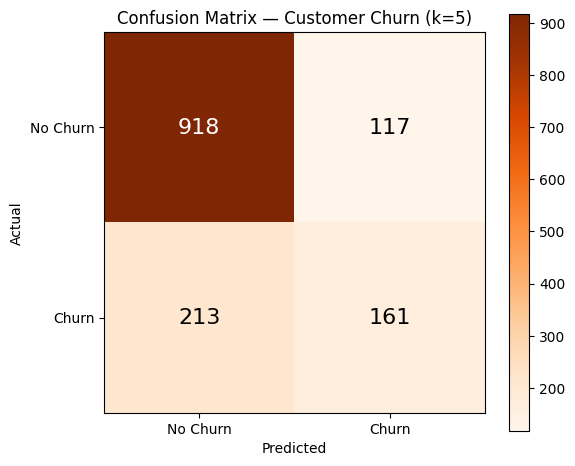

In [13]:
# Confusion matrix visualisation
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(test_conf, interpolation='nearest', cmap='Oranges')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_yticklabels(['No Churn', 'Churn'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Customer Churn (k=5)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(test_conf[i, j]),
                ha='center', va='center', fontsize=16,
                color='white' if test_conf[i, j] > test_conf.max() / 2 else 'black')
plt.tight_layout()
plt.show()

In [14]:
print("\n=== Full Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))


=== Full Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.81      0.89      0.85      1035
       Churn       0.58      0.43      0.49       374

    accuracy                           0.77      1409
   macro avg       0.70      0.66      0.67      1409
weighted avg       0.75      0.77      0.75      1409



Notes
- Accuracy around ~80% — lower than the cancer dataset because churn is a harder problem.
- Recall for Churn is low — the model misses many actual churners.
- Root cause: KNN uses Euclidean distance on unscaled features; high-range columns (MonthlyCharges, TotalCharges) dominate the distance calculation.

### Step 6: Experiment and Improve

In [15]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    preds = knn_k.predict(X_test)
    results.append({
        'K':         k,
        'Accuracy':  accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall':    recall_score(y_test, preds),
    })
    print(f"K={k:2d}: Acc={results[-1]['Accuracy']:.4f}  "
          f"Prec={results[-1]['Precision']:.4f}  "
          f"Rec={results[-1]['Recall']:.4f}")

results_df = pd.DataFrame(results)
best_k   = int(results_df.loc[results_df['Accuracy'].idxmax(), 'K'])
best_acc = results_df['Accuracy'].max()
print(f"\n→ Best K by accuracy: {best_k}  (Accuracy: {best_acc:.4f})")

K= 1: Acc=0.7119  Prec=0.4570  Rec=0.4545
K= 3: Acc=0.7622  Prec=0.5657  Rec=0.4492
K= 5: Acc=0.7658  Prec=0.5791  Rec=0.4305
K= 7: Acc=0.7814  Prec=0.6260  Rec=0.4385
K= 9: Acc=0.7885  Prec=0.6532  Rec=0.4332
K=11: Acc=0.7871  Prec=0.6623  Rec=0.4037
K=15: Acc=0.7885  Prec=0.6696  Rec=0.4011

→ Best K by accuracy: 9  (Accuracy: 0.7885)


- K=1 severely overfits: near-perfect training accuracy, much lower test accuracy.
- Accuracy plateaus from K=7 onward — diminishing returns.
- Recall drops consistently as K grows — larger neighbourhoods make the model increasingly conservative about predicting churn.

### Step 7: Analysis and Recommendations

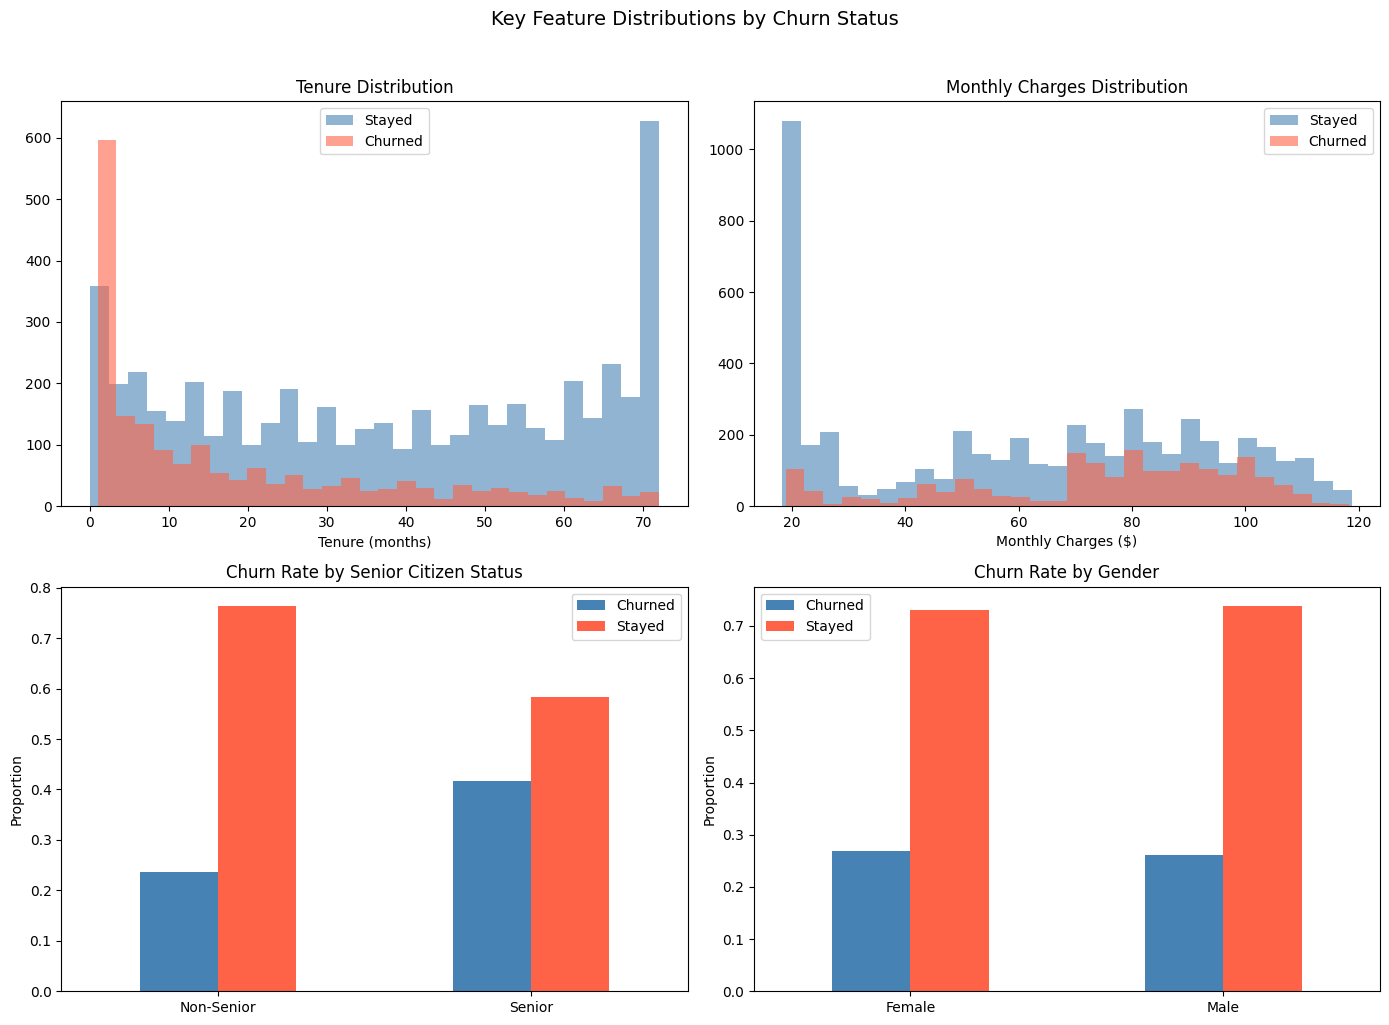

In [16]:
raw = df.copy()
raw['Churn_label'] = y.map({1: 'Churned', 0: 'Stayed'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tenure
axes[0, 0].hist(raw[raw['Churn_label'] == 'Stayed']['tenure'],  alpha=0.6, bins=30, color='steelblue', label='Stayed')
axes[0, 0].hist(raw[raw['Churn_label'] == 'Churned']['tenure'], alpha=0.6, bins=30, color='tomato',   label='Churned')
axes[0, 0].set_title('Tenure Distribution'); axes[0, 0].set_xlabel('Tenure (months)'); axes[0, 0].legend()

# 2. Monthly Charges
axes[0, 1].hist(raw[raw['Churn_label'] == 'Stayed']['MonthlyCharges'],  alpha=0.6, bins=30, color='steelblue', label='Stayed')
axes[0, 1].hist(raw[raw['Churn_label'] == 'Churned']['MonthlyCharges'], alpha=0.6, bins=30, color='tomato',   label='Churned')
axes[0, 1].set_title('Monthly Charges Distribution'); axes[0, 1].set_xlabel('Monthly Charges ($)'); axes[0, 1].legend()

# 3. Senior Citizen churn rate
sc_churn = raw.groupby('SeniorCitizen')['Churn_label'].value_counts(normalize=True).unstack()
sc_churn.index = ['Non-Senior', 'Senior']
sc_churn.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'tomato'], rot=0)
axes[1, 0].set_title('Churn Rate by Senior Citizen Status'); axes[1, 0].set_ylabel('Proportion'); axes[1, 0].legend(title='')

# 4. Gender churn rate
g_churn = raw.groupby('gender')['Churn_label'].value_counts(normalize=True).unstack()
g_churn.index = ['Female', 'Male']
g_churn.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'tomato'], rot=0)
axes[1, 1].set_title('Churn Rate by Gender'); axes[1, 1].set_ylabel('Proportion'); axes[1, 1].legend(title='')

plt.suptitle('Key Feature Distributions by Churn Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

What is the best model's accuracy?

In [17]:
best_row = results_df[results_df['K'] == best_k].iloc[0]
print(f"Best K value:   {best_k}")
print(f"Test Accuracy:  {best_row['Accuracy']*100:.1f}%")
print(f"Test Precision: {best_row['Precision']*100:.1f}%")
print(f"Test Recall:    {best_row['Recall']*100:.1f}%")

Best K value:   9
Test Accuracy:  78.9%
Test Precision: 65.3%
Test Recall:    43.3%


What features seem most important? (You can explore this by looking at feature distributions)

1. Short-tenure customers churn far more. Customers staying beyond ~12 months are significantly more loyal.
2. Higher monthly charges → higher churn risk. Fiber optic customers in particular are the riskiest segment.
3. Month-to-month contracts are the single strongest churn predictor; two-year contract customers rarely leave.
4. Senior citizens churn at a higher rate than non-seniors.

What would you recommend to the company based on your model?

1. Incentivise long-term contracts — offer meaningful discounts to switch from month-to-month to annual plans.
2. Launch early retention campaigns targeting the 0–12 month cohort, especially Fiber optic + electronic-check customers.
3. Introduce loyalty rewards at the 6-month mark to bridge the early-churn window.
4. Design senior-friendly plans or dedicated support channels to reduce their elevated churn rate.

What are the limitations of your model?


Limitation: Unscaled features bias KNN distances
// Mitigation: Add `StandardScaler` before fitting

Limitiation: Low recall on churners (imbalanced classes)
// Mitigation: Use SMOTE oversampling or adjust decision threshold

Limitiation: No built-in feature importance
// Mitigation: Switch to Random Forest for explainability

Limitiation: Slow prediction (O(n) per query)
// Mitigation: Use approximate NN or a tree-based model at scale
